<a href="https://colab.research.google.com/github/saadbinather/CV-CNN-diary/blob/main/Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install segmentation-models-pytorch torch torchvision

In [ ]:
import segmentation_models_pytorch as smp
import torch

# 1. Model define karein
# Hum UNet architecture use kar rahe hain with ResNet34 backbone
# encoder_weights='imagenet' yahan ImageNet ke weights load karega
model = smp.Unet(
    encoder_name="resnet34",        # Backbone choose karein
    encoder_weights="imagenet",     # ImageNet weights use karein
    in_channels=3,                  # RGB images ke liye 3 channels
    classes=1,                      # Binary segmentation (e.g., mask vs background)
    activation='sigmoid'            # Output ko 0-1 ke darmiyan lane ke liye
)

# 2. Dummy Input banayein (Batch_size, Channels, Height, Width)
# ImageNet models usually 224x224 ya higher expect karte hain
dummy_input = torch.randn(1, 3, 256, 256)

# 3. Forward Pass
mask_prediction = model(dummy_input)

print(f"Input Shape: {dummy_input.shape}")
print(f"Output Mask Shape: {mask_prediction.shape}")

# 4. Training ke liye Loss aur Optimizer
loss_fn = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

100%|██████████| 792M/792M [00:56<00:00, 14.0MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.12MB/s]


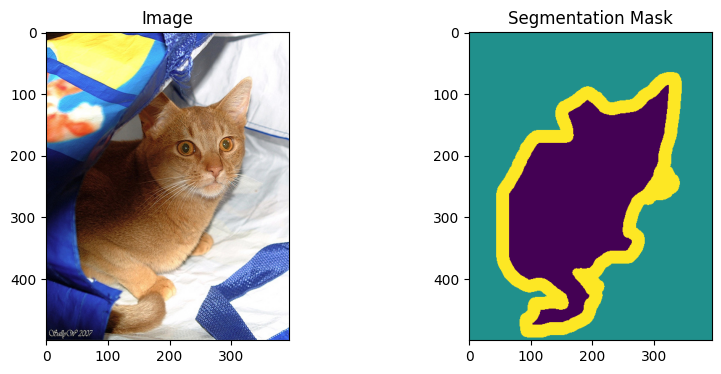

In [ ]:
print(mask.size)

(394, 500)


In [ ]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [ ]:
dataset = OxfordIIITPet(
    root="data",
    download=False,
    target_types="segmentation",
    transform=transform
)

In [ ]:
loader = DataLoader(dataset, batch_size=4, shuffle=True)

In [ ]:
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

image_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.PILToTensor()
])

In [ ]:
from torchvision.datasets import OxfordIIITPet

class PetDataset(torch.utils.data.Dataset):

    def __init__(self):
        self.dataset = OxfordIIITPet(
            root="data",
            download=False,
            target_types="segmentation"
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, mask = self.dataset[idx]

        image = image_transform(image)
        mask = mask_transform(mask).squeeze(0)

        return image, mask

In [ ]:
dataset = PetDataset()

loader = DataLoader(dataset, batch_size=4, shuffle=True)

In [ ]:
images, masks = next(iter(loader))

print(images.shape)
print(masks.shape)

torch.Size([4, 3, 128, 128])
torch.Size([4, 128, 128])


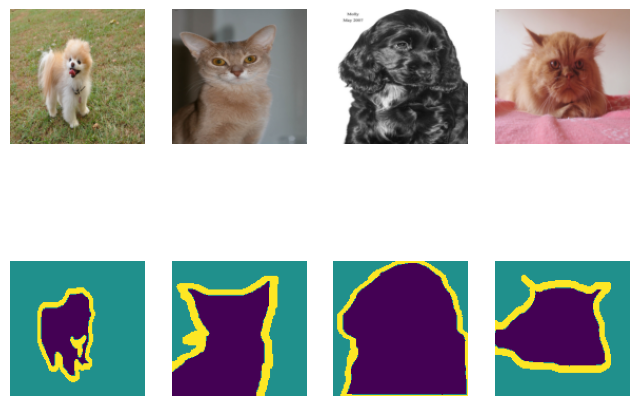

In [ ]:
plt.figure(figsize=(8,6))

for i in range(4):

    plt.subplot(2,4,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.axis("off")

    plt.subplot(2,4,i+5)
    plt.imshow(masks[i])
    plt.axis("off")

plt.show()